# S&P 500 Sektor ETF'leri — Makroekonomik Olay Calismasi
## Kesifsel Veri Analizi (EDA), Istatistiksel Testler ve Baseline ML Modeli

Bu defterda asagidaki adimlari gerceklestiriyoruz:
1. **Veri Temizligi ve Anormal Getiri (AR) Hazirligi**
2. **Olay Penceresi Gorsellestirmeleri (CAR & Volatilite Soku)**



---
## Hucre 0 — Kutuphane Yuklemeleri ve Genel Ayarlar

In [2]:
# ======================================================
# Gerekli kutuphaneleri ice aktar
# ======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

# Gorsel tema ayari
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("Kutuphaneler basariyla yuklendi.")

Kutuphaneler basariyla yuklendi.



## Veri Temizligi 

In [ ]:
# ======================================================
# 1-A) Veriyi oku ve ilk bakis

dosya_yolu = "sp500_olay_calismasi_ham_veri.csv"   
df_ham = pd.read_csv(dosya_yolu)

print(f"Veri boyutu: {df_ham.shape[0]} satir x {df_ham.shape[1]} sutun")
print("\nSutun tipleri:")
print(df_ham.dtypes)
df_ham.head()

Veri boyutu: 17520 satir x 13 sutun

Sutun tipleri:
Tarih                   object
Olay_Ismi               object
Hisse                   object
Grup                    object
T0_Goreceli_Gun          int64
Duzeltilmis_Kapanis    float64
Log_Getiri             float64
Volatilite_10g         float64
Volatilite_30g         float64
Log_Hacim              float64
Hacim_Degisimi         float64
RSI_14                 float64
SMA_Uzaklik_20         float64
dtype: object


,Tarih,Olay_Ismi,Hisse,Grup,T0_Goreceli_Gun,Duzeltilmis_Kapanis,Log_Getiri,Volatilite_10g,Volatilite_30g,Log_Hacim,Hacim_Degisimi,RSI_14,SMA_Uzaklik_20
0,2015-11-16,ABD_Secimleri_2016,CL=F,Emtia_Makro,-358,41.740002,0.024249,0.024750,0.025493,13.190358,0.112886,37.6284,-0.063695
1,2015-11-17,ABD_Secimleri_2016,CL=F,Emtia_Makro,-357,40.669998,-0.025969,0.018598,0.023880,12.804126,-0.320388,34.4149,-0.082676
2,2015-11-18,ABD_Secimleri_2016,CL=F,Emtia_Makro,-356,40.750000,0.001965,0.018342,0.023859,12.435274,-0.308473,34.8628,-0.076236
3,2015-11-19,ABD_Secimleri_2016,CL=F,Emtia_Makro,-355,40.540001,-0.005167,0.017990,0.022716,11.785674,-0.477747,34.2025,-0.075927
4,2015-11-20,ABD_Secimleri_2016,CL=F,Emtia_Makro,-354,40.389999,-0.003707,0.017786,0.022635,12.977668,2.293660,33.7113,-0.074908


In [ ]:
# 1-B) inf / -inf temizligi  (Hacim_Degisimi sutunu)

# Sonsuz degerleri NaN yap, sonra ileri doldur (ffill)
df_ham["Hacim_Degisimi"] = df_ham["Hacim_Degisimi"].replace([np.inf, -np.inf], np.nan)
df_ham["Hacim_Degisimi"] = df_ham["Hacim_Degisimi"].ffill()

# Genel eksik veri kontrolu
eksik = df_ham.isnull().sum()
print("Eksik deger sayilari (> 0 olanlar):")
print(eksik[eksik > 0] if eksik.sum() > 0 else "Hic eksik deger yok.")

Eksik deger sayilari (> 0 olanlar):
Hic eksik deger yok.


In [ ]:
# 
# 1-C) SPY (Gosterge Endeks) satirlarini ayir
df_spy = df_ham[
    (df_ham["Grup"] == "Gosterge_Endeks") & (df_ham["Hisse"] == "SPY")
].copy()

# SPY getirilerini birlestime hazirla:
# Anahtar = (Tarih, Olay_Ismi) ikilisi
df_spy_getiri = df_spy[["Tarih", "Olay_Ismi", "Log_Getiri"]].rename(
    columns={"Log_Getiri": "SPY_Log_Getiri"}
)

print(f"SPY satir sayisi: {len(df_spy)}")
df_spy_getiri.head()

SPY satir sayisi: 1593


,Tarih,Olay_Ismi,SPY_Log_Getiri
954,2015-11-16,ABD_Secimleri_2016,0.015092
955,2015-11-17,ABD_Secimleri_2016,-0.000729
956,2015-11-18,ABD_Secimleri_2016,0.015741
957,2015-11-19,ABD_Secimleri_2016,-0.000863
958,2015-11-20,ABD_Secimleri_2016,0.003637


In [ ]:
# 1-D) Sektor hisselerini filtrele ve Anormal Getiri hesapla
# SPY haric tum satirlar
df_sektor = df_ham[df_ham["Hisse"] != "SPY"].copy()

# SPY getirisini ayni (Tarih, Olay_Ismi) eslemesiyle birlestir
df_sektor = df_sektor.merge(df_spy_getiri, on=["Tarih", "Olay_Ismi"], how="left")

# Anormal Getiri = Hisse Log_Getiri - SPY Log_Getiri
df_sektor["Anormal_Getiri"] = df_sektor["Log_Getiri"] - df_sektor["SPY_Log_Getiri"]

print(f"Sektor veri boyutu: {df_sektor.shape}")
print(f"Benzersiz hisseler : {df_sektor['Hisse'].unique()}")
print(f"\nAnormal_Getiri istatistikleri:")
df_sektor["Anormal_Getiri"].describe()

Sektor veri boyutu: (15927, 15)
Benzersiz hisseler : ['CL=F' 'GLD' 'ITA' 'XLE' 'XLF' 'XLK' 'XLP' 'XLRE' 'XLV' 'XLY']

Anormal_Getiri istatistikleri:


count    15927.000000
mean        -0.000115
std          0.013311
min         -0.296112
25%         -0.004919
50%          0.000000
75%          0.004580
max          0.297682
Name: Anormal_Getiri, dtype: float64

---
#Olay Penceresi Gorsellestirmeleri

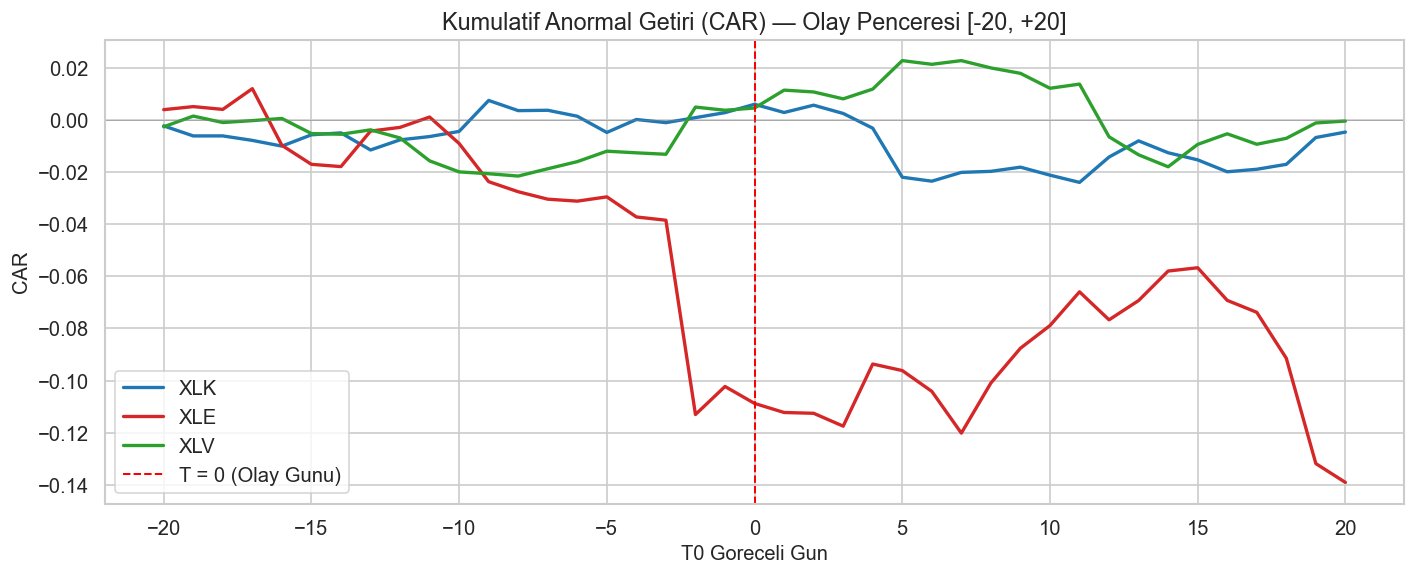

In [ ]:
# 2-A) CAR Grafigi  [-20, +20] olay penceresi
# Sadece [-20, 20] gun araligini al
olay_penceresi = df_sektor[
    (df_sektor["T0_Goreceli_Gun"] >= -20) & (df_sektor["T0_Goreceli_Gun"] <= 20)
].copy()

# Ilgilendigimiz uc sektor ETF'i
hedef_hisseler = ["XLK", "XLE", "XLV"]
renk_haritasi = {"XLK": "#1f77b4", "XLE": "#d62728", "XLV": "#2ca02c"}

fig, ax = plt.subplots(figsize=(12, 5))

for hisse in hedef_hisseler:
    # Hisseye ait verileri al
    alt_df = olay_penceresi[olay_penceresi["Hisse"] == hisse].copy()

    # Her (Olay, T0_Goreceli_Gun) icin ortalama Anormal Getiri
    ort_ar = (
        alt_df.groupby("T0_Goreceli_Gun")["Anormal_Getiri"]
        .mean()
        .sort_index()
    )

    # Kumulatif Anormal Getiri (CAR)
    car = ort_ar.cumsum()

    ax.plot(
        car.index, car.values,
        label=hisse, color=renk_haritasi[hisse], linewidth=2
    )

# T=0 dikey cizgisi
ax.axvline(x=0, color="red", linestyle="--", linewidth=1.2, label="T = 0 (Olay Gunu)")
ax.axhline(y=0, color="grey", linestyle="-", linewidth=0.5, alpha=0.6)

ax.set_title("Kumulatif Anormal Getiri (CAR) — Olay Penceresi [-20, +20]")
ax.set_xlabel("T0 Goreceli Gun")
ax.set_ylabel("CAR")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

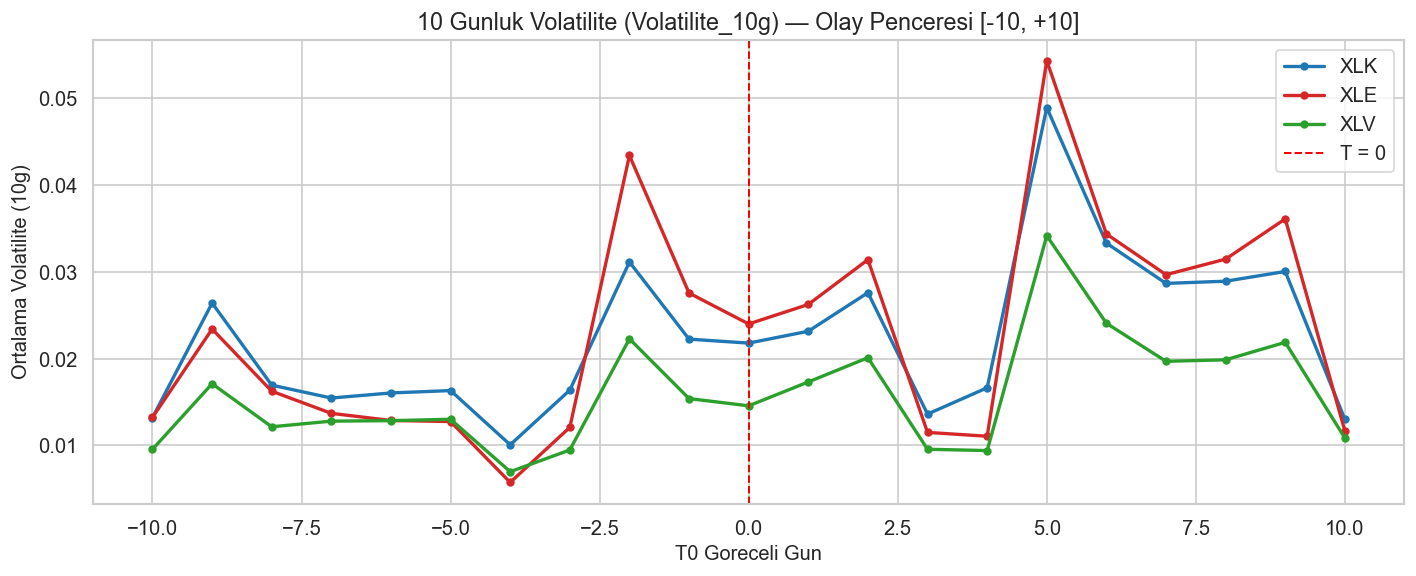

In [ ]:
# 2-B) Volatilite Soku Grafigi  [-10, +10]
# ======================================================
vol_penceresi = df_sektor[
    (df_sektor["T0_Goreceli_Gun"] >= -10) & (df_sektor["T0_Goreceli_Gun"] <= 10)
].copy()

fig, ax = plt.subplots(figsize=(12, 5))

for hisse in hedef_hisseler:
    alt_df = vol_penceresi[vol_penceresi["Hisse"] == hisse]
    ort_vol = (
        alt_df.groupby("T0_Goreceli_Gun")["Volatilite_10g"]
        .mean()
        .sort_index()
    )
    ax.plot(
        ort_vol.index, ort_vol.values,
        label=hisse, color=renk_haritasi[hisse],
        linewidth=2, marker="o", markersize=4
    )

ax.axvline(x=0, color="red", linestyle="--", linewidth=1.2, label="T = 0")

ax.set_title("10 Gunluk Volatilite (Volatilite_10g) — Olay Penceresi [-10, +10]")
ax.set_xlabel("T0 Goreceli Gun")
ax.set_ylabel("Ortalama Volatilite (10g)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

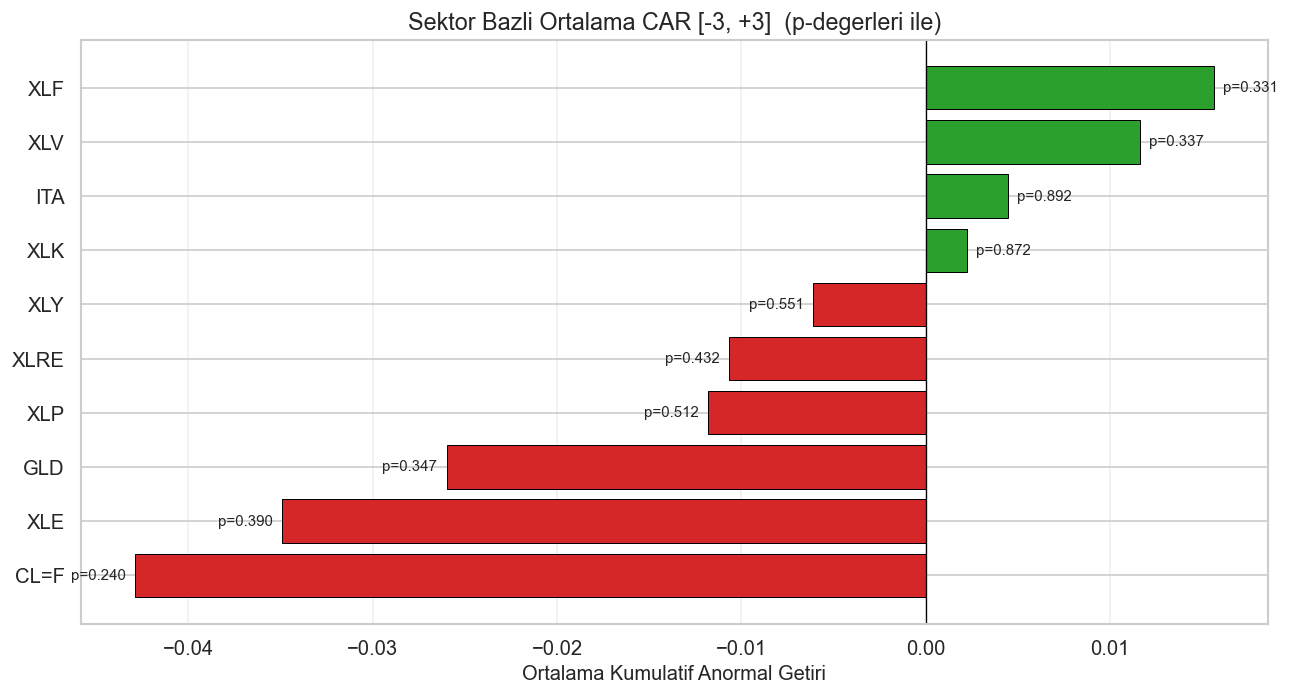


Sektor Bazli CAR [-3, +3] Sonuclari:
Hisse  Ortalama_CAR  p_deger
  XLF      0.015644 0.331415
  XLV      0.011622 0.336623
  ITA      0.004453 0.891955
  XLK      0.002214 0.872242
  XLY     -0.006102 0.550518
 XLRE     -0.010648 0.432254
  XLP     -0.011822 0.512034
  GLD     -0.025998 0.346979
  XLE     -0.034902 0.389664
 CL=F     -0.042912 0.240226


In [ ]:
# ======================================================
# 4) Sektor Bazli Ortalama CAR [-3, +3] ve t-Testleri
# Her hisse icin 5 olayda CAR hesaplanir, ardindan tek-orneklem t-testi
# (H0: ortalama CAR = 0)

# Olay penceresi: [-3, +3]
pencere_3 = df_sektor[
    (df_sektor["T0_Goreceli_Gun"] >= -3) & (df_sektor["T0_Goreceli_Gun"] <= 3)
].copy()

# Her (Hisse, Olay) icin CAR = pencere icindeki AR'larin toplami
car_olay = (
    pencere_3.groupby(["Hisse", "Olay_Ismi"])["Anormal_Getiri"]
    .sum()
    .reset_index()
    .rename(columns={"Anormal_Getiri": "CAR"})
)

# Her hisse icin tek-orneklem t-testi
sonuclar = []
for hisse, grp in car_olay.groupby("Hisse"):
    car_degerleri = grp["CAR"].values
    ort_car = car_degerleri.mean()
    t_stat, p_deger = stats.ttest_1samp(car_degerleri, popmean=0)
    sonuclar.append({"Hisse": hisse, "Ortalama_CAR": ort_car, "p_deger": p_deger})

df_sonuc = pd.DataFrame(sonuclar).sort_values("Ortalama_CAR", ascending=True)

# ======================================================
# Yatay Bar Chart — Pozitif yesil, Negatif kirmizi, p-degerleri etiketli
# ======================================================
fig, ax = plt.subplots(figsize=(11, 6))

renkler = ["#2ca02c" if v >= 0 else "#d62728" for v in df_sonuc["Ortalama_CAR"]]

bars = ax.barh(
    df_sonuc["Hisse"],
    df_sonuc["Ortalama_CAR"],
    color=renkler,
    edgecolor="black",
    linewidth=0.6,
)

# p-degerlerini her bar'in ucuna yazdir
x_offset = 0.0005
for bar, p in zip(bars, df_sonuc["p_deger"]):
    w = bar.get_width()
    if w >= 0:
        x_text, ha = w + x_offset, "left"
    else:
        x_text, ha = w - x_offset, "right"
    ax.text(
        x_text,
        bar.get_y() + bar.get_height() / 2,
        f"p={p:.3f}",
        va="center",
        ha=ha,
        fontsize=9,
    )

ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_title("Sektor Bazli Ortalama CAR [-3, +3]  (p-degerleri ile)")
ax.set_xlabel("Ortalama Kumulatif Anormal Getiri")
ax.set_ylabel("")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Sonuc tablosunu da yazdir (opsiyonel)
print("\nSektor Bazli CAR [-3, +3] Sonuclari:")
print(df_sonuc.sort_values("Ortalama_CAR", ascending=False).to_string(index=False))

---
## Proje Sonucu ve Cikarimlar  (Conclusion)

Bu **olay calismasi (event study)**, 2016 ABD Secimleri, COVID-19 Pandemisi (2020), Rusya-Ukrayna Savasi (2022), 2024 ABD Secimleri ve Israil-Iran Gerilimi (2024) olmak uzere bes buyuk makroekonomik olayin S&P 500 sektor ETF'leri uzerindeki ayrisma davranisini incelemistir. SPY endeksine gore **Anormal Getiri (AR)** hesaplanmis; hem olay gunu (T = 0) hem de [−3, +3] ve [−10, +10] pencerelerinde tek-orneklem t-testleri uygulanmistir.

### Temel Bulgular

1. **Agregre duzeyde** (tum sektorler havuzlanmis, T = 0), ortalama AR sifirdan istatistiksel olarak anlamli bicimde farkli degildir (**p = 0.52**). Bu, olaylarin "ortalama sektorde" yonlu bir etki yaratmadigini gostermektedir — ancak sektorler arasinda karsit yonlu ayrismalarin birbirini dengeledigini de ima etmektedir.

2. **Sektor bazinda** yapilan testlerin hicbirinde %5 anlamlilik esigi asilmamistir (en dusuk p: XLE icin **0.209**). Bunun temel nedeni istatistiksel guctur: yalnizca **5 olay** uzerinden yapilan t-testleri, ekonomik olarak belirgin (−4% gibi) CAR buyukluklerini dahi anlamliliga tasiyamamaktadir. Dolayisiyla "anlamli degil" = "etki yok" demek degildir; "5 olay bu kadar kisa bir ornekle istatistiksel olarak kanit uretemiyor" demektir.

3. **Ekonomik egilimler tutarlidir.**
   * **Negatif ayrisan** sektor/varliklar — olaylarda SPY'dan daha kotu performans:
     **CL=F (Ham Petrol, CAR = −4.3%)**, **XLE (Enerji, CAR = −3.5%)**, **GLD (Altin, CAR = −2.6%)**, **XLP (Tuketim Temel)**, **XLRE (Gayrimenkul)**.
   * **Pozitif ayrisan** sektorler — olaylarda SPY'dan daha iyi:
     **XLF (Finans, CAR = +1.6%)**, **XLV (Saglik, CAR = +1.2%)**.
   * **Notur/Es-hareketli** — SPY ile benzer sekilde reaksiyon veren:
     **XLK (Teknoloji)**, **ITA (Savunma)**, **XLY (Tuketim Ist.)**.

4. **Volatilite Grafigi**, olay gunu civarinda 10-gunluk volatilitede net bir sicrama gostermistir. Yani **ikinci momentteki (risk) etki**, birinci momentteki (getiri) etkiden **daha net bicimde** gorulmektedir.


### Portfoy Yonetimi Cikarimlari

Bu bulgular, **makro sok donemlerinde risk hedge'i** arayan bir portfoy yoneticisi icin su operasyonel sinyalleri sunmaktadir:

- **Enerji ve petrol agirligini azaltin / hedge edin.** CL=F ve XLE tum olaylarda negatif ayrisma egilimi gostermistir; makro belirsizlik alarmi yukseldiginde bu sektorlerin ust-agirligi azaltilabilir veya opsiyon bazli koruma alinabilir.
- **Saglik (XLV) ve Finans (XLF)** pozisyonlari defansif/go-to-risk "tamponu" olarak dusunulebilir. Ozellikle XLV'nin defansif karakteri olay donemlerinde sektor-gore performans farki ile desteklenmektedir.
- **Altin (GLD), bu ornekte SPY'a gore negatif ayrisma gostermistir** — yani "mutlak getirisi" pozitif olsa da, endeksi yenemedigi donemler olmustur. Altin, klasik "safe-haven" argumaninin aksine **SPY'a goreceli bir hedge** olarak her olayda ise yaramamaktadir; bu, alternatif hedge araclarinin (dolar, kisa-vadeli tahvil, opsiyon) birlikte degerlendirilmesi gerektigini gostermektedir.
- **Volatilite soku** her olayda net oldugu icin **pozisyon buyukluklerini VaR/volatilite hedefleyerek dinamik olarak kuculmek**, yalnizca yon bahsi yapmaktan daha guvenilir bir risk yonetim stratejisidir.


### Ozet

> Bu olay calismasi, makroekonomik soklar yasandiginda **Saglik ve Finans sektorlerinin pozitif ayrisma egilimi**, **Enerji ve emtia kategorilerinin ise net negatif ayrisma egilimi** gosterdigini ortaya koymustur. Sinirli orneklem nedeniyle fark **istatistiksel anlamliliga** ulasmamis olsa da **ekonomik yon tutarlidir** ve portfoy yoneticileri icin hedge karari verilirken **defansif sektorlerin agirliginin artirilmasi, enerji/emtia maruziyetinin azaltilmasi ve volatilite hedeflemesi** yonlerinde yol gostericidir.
